# 1. <a id='toc1_'></a>[Ingeniería de características: sentimiento y variables temporales](#toc0_)

**Trabajo (PEC3/M3.3):** M3.3 - Construcción de variables de sentimiento y temporales  
**Máster:** Ciencia de Datos (UOC)  
**Autor:** Antonio Barrera Mora  
**Notebook:** 03_Ingenieria_Caracteristicas.ipynb

## 1.1. <a id='toc1_1_'></a>[Objetivo](#toc0_)

El objetivo de esta fase es transformar la **matriz maestra de eventos** (resultado de M3.2) en un conjunto de características analíticas (*features*) operativas, capaces de capturar la **deriva conductual** y las **anomalías temporales** de los usuarios.

La estrategia de ingeniería la fundamentamos en tres pilares metodológicos alineados con el modelo CPIR:

1.  **Detección de la 'Deriva Afectiva' (Fase de Ideación/Preparación):**
    *   Construcción de líneas base de sentimiento por usuario (Media Móvil de 30 días).
    *   Cálculo de desviaciones estandarizadas (*Z-Score* intrausuario) para identificar deterioro emocional respecto al patrón habitual.
    *   Generación de binarios de alerta temprana (negatividad moderada/severa).

2.  **Monitorización de 'Desviación Operativa' (Fase de Acción):**
    *   *Z-Scores* de volumen de actividad (Logon, HTTP, USB) para detectar picos de hiperactividad anómalos.
    *   Ratios de actividad en ventanas de riesgo (*after-hours ratio*).

3.  **Análisis de 'Regularidad' (Estabilización del patrón):**
    *   Derivación de métricas de consistencia horaria (media y desviación estándar de la hora de conexión) a partir de los logs crudos.
    *   Esta métrica es crítica: un atacante que cambia sus horarios habituales (e.g., trabajar solo de madrugada) presenta una alta señal de riesgo.

> **Nota de Privacidad (Privacy by Design):** Todas las métricas de desviación (*Z-Scores*) calculadas respecto a la línea base *individual* de cada usuario, no respecto a la media global. Esto garantiza que el sistema detecte anomalías sobre el comportamiento propio del empleado evitando sesgos comparativos y protegiendo la privacidad.

> **Nota metodológica:** Para evitar fugas de datos (Data Leakage), todas las estadísticas de línea base (medias móviles) las calculamos con un retraso de un día (`shift(1)`). La predicción del día $t$ solo depende de la historia $t-1, t-2...$." 

## 1.2. <a id='toc1_2_'></a>[Fuentes de datos](#toc0_)

Para la construcción de las variables, este *notebook* integra dos niveles de granularidad:

| Fuente | Ruta | Propósito en M3.3 |
| :--- | :--- | :--- |
| **Matriz Maestra (Procesada)** | `../src/data/processed/master_behavioral_matrix.parquet` | Fuente primaria. Contiene la actividad agregada por día (`usuario-día`) y las variables estáticas (Psicometría/LDAP). Utilizamos para la mayoría de features temporales y de sentimiento. |
| **Logon Crudo (Raw)** | `../src/data/raw/logon.csv` | **Excepción de granularidad:** Accede al archivo original *raw* exclusivamente para extraer la hora exacta de cada inicio de sesión. La matriz maestra solo contiene conteos (`total_logon_activity`), por lo que es imposible calcular la "media de hora de conexión" sin los timestamps originales. |


## 1.3. <a id='toc1_3_'></a>[Salidas esperadas](#toc0_)

El resultado de este notebook son dos artefactos que alimentarán directamente el modelado de M3.4:

1.  **`../src/data/processed/feature_matrix_v1.parquet`**:
    *   La **matriz de características final** (~330.000 filas).
    *   Incluye las variables originales, las ingenierías temporales, las métricas de sentimiento y los *Z-Scores*.
    *   Lista para ingesta por algoritmos de detección de anomalías (*Isolation Forest / Autoencoders*).

2.  **`../src/data/processed/feature_shortlist_m34.csv`**:
    *   Un informe tabular de auditoría que valida la calidad de las variables creadas (tasa de nulos, dispersión, redundancias).
    *   Sirve como justificación para la selección final de predictores antes del entrenamiento.

**Tabla de contenidos**<a id='toc0_'></a>    
- 1. [Ingeniería de características: sentimiento y variables temporales](#toc1_)    
  - 1.1. [Objetivo](#toc1_1_)    
  - 1.2. [Fuentes de datos](#toc1_2_)    
  - 1.3. [Salidas esperadas](#toc1_3_)    
- 2. [Carga de datos de entrada y contexto de fase](#toc2_)    
  - 2.1. [Configuración y carga inicial](#toc2_1_)    
- 3. [Decisión metodológica previa: uso de LDAP como snapshot](#toc3_)    
    - 3.1.1. [📖 Justificación metodológica](#toc3_1_1_)    
    - 3.1.2. [🔍 Implicación analítica](#toc3_1_2_)    
- 4. [Exploración estructural de fuentes (resumen consolidado)](#toc4_)    
  - 4.1. [Resumen consolidado de datasets event-driven](#toc4_1_)    
  - 4.2. [Exploración dataset PSYCHOMETRIC (rasgos Big Five)](#toc4_2_)    
  - 4.3. [Exploración de LDAP (contexto organizativo)](#toc4_3_)    
  - 4.4. [Resumen de la Matriz Maestra integrada](#toc4_4_)    
  - 4.5. [Otras verificaciones críticas previas a la ingeniería:](#toc4_5_)    
- 5. [Construcción de variables para detección conductual](#toc5_)    
  - 5.1. [Features de sentimiento (sin *data leakage*)](#toc5_1_)    
  - 5.2. [Features temporales y de comportamiento diario](#toc5_2_)    
  - 5.3. [Variable compleja: regularidad horaria de conexión](#toc5_3_)    
  - 5.4. [ Selección final y exportación de feature matrix v1](#toc5_4_)    
- 6. [Evaluación rápida de características para M3.4](#toc6_)    
  - 6.1. [Diagnóstico de calidad por variable](#toc6_1_)    
  - 6.2. [Mapa de correlación para detectar redundancia](#toc6_2_)    
  - 6.3. [Generación de una shortlist para M3.4](#toc6_3_)    
  - 6.4. [Otras comprobaciones y gráficas de apoyo para la selección de features para M3.4](#toc6_4_)    
    - 6.4.1. [Histogramas con KDE para las top 6 variables del shortlist](#toc6_4_1_)    
    - 6.4.2. [Rangos de variables para fundamentar la decisión de normalizar en M3.4](#toc6_4_2_)    
    - 6.4.3. [Detección de dependencias no lineales mediante '*Mutual Information*'](#toc6_4_3_)    
    - 6.4.4. [🔍 Análisis de dependencias y ortogonalidad (*Mutual Information*)](#toc6_4_4_)    
- 7. [Cierre de fase: Ingeniería de características (M3.3)](#toc7_)    
  - 7.1. [✅ Entregables de M3.3](#toc7_1_)    
  - 7.2. [🔑 Decisiones metodológicas consolidadas](#toc7_2_)    
  - 7.3. [🚀 Enlace con M3.4 (Modelado no supervisado)](#toc7_3_)    
- 8. [Referencias](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 2. <a id='toc2_'></a>[Carga de datos de entrada y contexto de fase](#toc0_)

En esta fase transformamos la **matriz maestra conductual** (producto de M3.2) en un conjunto de variables analíticas operativas. El proceso de carga sigue una estrategia dual diseñada para preservar granularidad sin introducir redundancias:

1.  **Matriz maestra (`master_behavioral_matrix.parquet`):** Base principal que contiene actividad agregada diaria (`usuario-día`), sentimiento VADER, rasgos *Big Five* y contexto LDAP. Es el insumo para derivar métricas de deriva conductual, ventanas móviles y *Z-Scores* intrausuario.
2.  **Logon crudo (`logon.csv`):** Accedemos al archivo original exclusivamente para extraer la granularidad horaria de los inicios de sesión. Esta información no está disponible en la matriz agregada y es crítica para calcular estadísticos de regularidad temporal (media, desviación y rango horario).

Esta separación garantiza que la ingeniería de características sea **trazable, reproducible y libre de dependencias circulares**, preparando un dataset limpio y estructurado para la fase de modelado no supervisado (M3.4).

## 2.1. <a id='toc2_1_'></a>[Configuración y carga inicial](#toc0_)

Configuramos, cargamos y verificamos las fuentes de datos para asegurar que el proceso de ingeniería de características se base en un dataset limpio, estructurado y listo para transformaciones avanzadas. Este paso es crítico para garantizar la trazabilidad y reproducibilidad de las variables derivadas en M3.3.

In [4]:
# ============================================================
# 2.1. Configuracion de rutas y carga de datos de entrada
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path

# Definición de rutas base relativas al notebook (ubicado en /notebooks)
# Asumimos la estructura estandar: notebooks/ -> ../src/data/...
BASE_DIR = Path('..') / 'src'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
RAW_DIR = BASE_DIR / 'data' / 'raw'

# Rutas de entrada/salida específicas para M3.3
MASTER_PATH = PROCESSED_DIR / 'master_behavioral_matrix.parquet'
LOGON_RAW_PATH = RAW_DIR / 'logon.csv'
OUTPUT_PATH = PROCESSED_DIR / 'feature_matrix_v1.parquet'

# Carga de la matriz maestra (salida de M3.2)
# Contiene: actividad diaria agregada, sentimiento, psicometria y contexto LDAP
print("⏳ Cargando matriz maestra desde M3.2 [...]")
master = pd.read_parquet(MASTER_PATH)

# Normalización temporal: asegurar que 'day' sea datetime para operaciones de ventana y ordenamiento
master['day'] = pd.to_datetime(master['day'])

# Ordenamiento crítico: [user, day] es requisito para ventanas moviles (rolling/shift)
# Sin este orden, las derivaciones temporales mezclarían usuarios o romperían la cronología historica
master = master.sort_values(['user', 'day']).reset_index(drop=True)

# Validacion rapida de cobertura y esquema antes de proceder con feature engineering
print("\n✅ MATRIZ MAESTRA CARGADA - VALIDACIÓN INICIAL")
print(f"📊 Dimensiones: {master.shape}")
print(f"🔑 Columnas: {len(master.columns)} features")
print(f"📅 Rango temporal: {master['day'].min().date()} -> {master['day'].max().date()}")
print(f"👥 Usuarios únicos: {master['user'].nunique()}")

⏳ Cargando matriz maestra desde M3.2 [...]

✅ MATRIZ MAESTRA CARGADA - VALIDACIÓN INICIAL
📊 Dimensiones: (330452, 17)
🔑 Columnas: 17 features
📅 Rango temporal: 2010-01-02 -> 2011-05-17
👥 Usuarios únicos: 1000


In [5]:
# NOTA: logon.csv se cargará únicamente en el bloque de regularidad horaria.
# Cargarlo aquí innecesariamente duplicaría consumo de RAM y entorpecería la trazabilidad modular.

In [6]:
# Verificamos que las columnas núcleo existen antes de continuar
required_cols = ['user', 'day', 'avg_sentiment', 'total_logon_activity', 'after_hours_activity']
missing = [c for c in required_cols if c not in master.columns]
if missing:
    raise KeyError(f"⚠️ Columnas críticas faltantes en la matriz maestra: {missing}")
print("✅ Esquema validado: todas las columnas núcleo presentes.")

✅ Esquema validado: todas las columnas núcleo presentes.


# 3. <a id='toc3_'></a>[Decisión metodológica previa: uso de LDAP como snapshot](#toc0_)

En esta fase se mantiene la decisión arquitectónica de integrar LDAP como un **snapshot estático** correspondiente al mes de mayo de 2011, garantizando continuidad con la estrategia de ingestión definida en M3.2.

### 3.1.1. <a id='toc3_1_1_'></a>[📖 Justificación metodológica](#toc0_)
- **Enfoque en contexto vigente:** El objetivo de M3.3 es modelar el comportamiento operativo reciente proyectando al empleado sobre su estructura organizativa actual (rol, departamento, unidad funcional) al cierre del periodo de estudio.
- **Delimitación del alcance:** Incorporar la evolución histórica completa de cargos y departamentos (tipo *Slowly Changing Dimension*) añadiría una capa de complejidad temporal que excede los objetivos de esta fase y podría introducir ruido en la construcción de líneas base conductuales.
- **Tratamiento de bajas/ausencias:** Los usuarios que no figuran en el snapshot final (e.g., empleados dados de baja antes de mayo-2011) se mantienen con valores `NaN` en las variables organizativas. Esto evita asignaciones erróneas o retroactivas y preserva la integridad temporal del dataset.

### 3.1.2. <a id='toc3_1_2_'></a>[🔍 Implicación analítica](#toc0_)
- **Reducción de dimensionalidad y ruido:** Al fijar el contexto organizativo, simplificamos el espacio de características para los algoritmos de detección no supervisada, priorizando señales conductuales dinámicas sobre metadatos administrativos.
- **Validez forense preservada:** Esta decisión no invalida la capacidad de análisis retrospectivo; un estudio forense avanzado podría requerir una dimensión SCD alineada a fecha, pero para la detección proactiva de anomalías (UEBA), el estado vigente al momento de la evaluación es el predictor contextual más robusto.

# 4. <a id='toc4_'></a>[Exploración estructural de fuentes (resumen consolidado)](#toc0_)

Antes de proceder con la ingeniería de características, documentamos la composición, cobertura y calidad básica de las fuentes que alimentarán la matriz de features. Esta validación preliminar cumple tres objetivos:

1.  **Trazabilidad:** Garantizar que los datos de entrada coinciden con los artefactos generados en M3.2.
2.  **Detección temprana de anomalías:** Identificar desviaciones en volumen, rango temporal o tasa de nulos que podrían distorsionar las variables derivadas.
3.  **Contexto para interpretación:** Establecer expectativas realistas sobre la densidad de señal por fuente (e.g., `file` y `device` tienen cobertura parcial por diseño del CERT).

El enfoque es **consolidado**: en lugar de repetir el protocolo descriptivo de M3.1 para cada fuente, presentamos una vista tabular unificada que facilita la comparación cruzada y la auditoría rápida.

## 4.1. <a id='toc4_1_'></a>[Resumen consolidado de datasets event-driven](#toc0_)

In [8]:
# ============================================================
# 4.1. Resumen consolidado de datasets event-driven
# ============================================================
# Carga controlada de fuentes raw para validación estructural previa al feature engineering
# Se utilizan parse_dates=['date'] para garantizar coherencia temporal desde el origen

logon = pd.read_csv(RAW_DIR / 'logon.csv', parse_dates=['date'])
email = pd.read_csv(RAW_DIR / 'email.csv', parse_dates=['date'])
file = pd.read_csv(RAW_DIR / 'file.csv', parse_dates=['date'])
device = pd.read_csv(RAW_DIR / 'device.csv', parse_dates=['date'])

# Diccionario centralizado para iteración segura y escalable
datasets = {
    'logon': logon,
    'email': email,
    'file': file,
    'device': device,
}

# Construccion de perfil estructural por fuente
# Cada metrica responde a una pregunta de calidad específica para M3.3
rows = []
for name, df_ in datasets.items():
    rows.append({
        'dataset': name,
        'rows': int(df_.shape[0]),                      # Volumen absoluto
        'cols': int(df_.shape[1]),                      # Complejidad esquemática
        'date_min': df_['date'].min(),                  # Cobertura temporal inferior
        'date_max': df_['date'].max(),                  # Cobertura temporal superior
        'users': int(df_['user'].nunique()),            # Cobertura de población
        'records_per_user_mean': float(df_.groupby('user').size().mean()),  # Densidad media
        'records_per_user_median': float(df_.groupby('user').size().median()),# Densidad típica (robusta a outliers)
        'null_rate_mean': float(df_.isnull().mean().mean()),# Calidad global de datos
    })

# Visualizacion tabular para auditoría rápida
summary_df = pd.DataFrame(rows).sort_values('dataset').reset_index(drop=True)
# Calculo de cobertura relativa respecto a la matriz maestra (1000 usuarios)
summary_df['coverage_vs_master_pct'] = (summary_df['users'] / master['user'].nunique() * 100).round(1)

print('=' * 80)
print('RESUMEN ESTRUCTURAL DE FUENTES EVENT-DRIVEN')
print('=' * 80)
display(summary_df)

# Metricas cualitativas adicionales para contexto criminológico
print('\nIndicadores adicionales de contexto:')
print(f"- Emails con attachments: {(email['attachments'] > 0).sum()}")  # Señal de exfiltración potencial
print(f"- Valores únicos en device.activity: {device['activity'].dropna().unique().tolist()}")  # Validación de esquema

RESUMEN ESTRUCTURAL DE FUENTES EVENT-DRIVEN


,dataset,rows,cols,date_min,date_max,users,records_per_user_mean,records_per_user_median,null_rate_mean,coverage_vs_master_pct
0,device,405380,5,2010-01-02 07:21:06,2011-05-16 23:22:34,265,1529.735849,779.0,0.000000,26.5
1,email,2629979,11,2010-01-02 07:11:45,2011-05-16 21:16:26,1000,2629.979000,3002.0,0.132391,100.0
2,file,445581,6,2010-01-02 07:23:14,2011-05-16 23:22:34,264,1687.806818,647.0,0.000000,26.4
3,logon,854859,5,2010-01-02 06:49:00,2011-05-17 06:43:35,1000,854.859000,692.0,0.000000,100.0



Indicadores adicionales de contexto:
- Emails con attachments: 563296
- Valores únicos en device.activity: ['Connect', 'Disconnect']


## 4.2. <a id='toc4_2_'></a>[Exploración dataset PSYCHOMETRIC (rasgos Big Five)](#toc0_)

In [ ]:
# ============================================================
# 4.2. Exploracion dataset PSYCHOMETRIC (rasgos Big Five)
# ============================================================
# Carga desde processed (ya optimizado en M3.2) para consistencia con el pipeline
psychometric = pd.read_parquet(PROCESSED_DIR / 'psychometric.parquet')

print('=' * 60)
print('DATASET: Psychometric (OCEAN traits)')
print('=' * 60)
print(f'Shape: {psychometric.shape[0]:,} rows × {psychometric.shape[1]} cols')
print(f'Usuarios: {psychometric.shape[0]} (cobertura 100%)') # CERT r4.2: 1000 perfiles estáticos
print(f'Null rates:\n{psychometric.isnull().mean()}')  # Validacion de integridad: esperamos 0% nulos
print('Columnas (traits):', psychometric.columns.tolist())

# Estadisticos descriptivos para validar rangos esperados (10-50 en CERT)
print('\nEstadisticos OCEAN:')
print(psychometric[['O', 'C', 'E', 'A', 'N']].describe().round(2))
print()

DATASET: Psychometric (OCEAN traits)
Shape: 1,000 rows × 7 cols
Usuarios: 1000 (cobertura 100%)
Null rates:
employee_name    0.0
user_id          0.0
O                0.0
C                0.0
E                0.0
A                0.0
N                0.0
dtype: float64
Columnas (traits): ['employee_name', 'user_id', 'O', 'C', 'E', 'A', 'N']

Estadisticos OCEAN:
             O        C        E        A        N
count  1000.00  1000.00  1000.00  1000.00  1000.00
mean     33.17    30.65    29.20    28.82    29.61
std      10.64    11.29    10.96    11.17     4.94
min      10.00    10.00    10.00    10.00    14.00
25%      23.00    20.00    19.00    19.00    26.00
50%      36.00    33.00    28.00    27.00    29.00
75%      42.00    40.00    39.00    39.00    33.00
max      50.00    50.00    50.00    50.00    49.00



## 4.3. <a id='toc4_3_'></a>[Exploración de LDAP (contexto organizativo)](#toc0_)

In [10]:
# ============================================================
# 4.3. Exploración dataset LDAP (snapshot organizativo - Mayo 2011)
# ============================================================
# LDAP se mantiene en raw como snapshot historico; se usa el más reciente para contexto vigente
ldap = pd.read_csv(RAW_DIR / 'ldap.csv')

print('=' * 60)
print('DATASET: LDAP (Organizacional - snapshot May 2011)')
print('=' * 60)
print(f'Shape: {ldap.shape[0]:,} rows × {ldap.shape[1]} cols')
print(f'Usuarios: {ldap.shape[0]}')  # Cobertura parcial: 845/1000 (bajas naturales del periodo)
print(f'Null rates:\n{ldap.isnull().mean()}')  # Campos como 'team' o 'supervisor' pueden tener nulos por diseño
print('Columnas:', ldap.columns.tolist())

# Validacion de cardinalidad en variables categoricas para feature engineering posterior
print('\nValores en categóricas:')
print(f'  Roles distintos: {ldap["role"].nunique()}')  # ~41 roles en CERT r4.2
print(f'  Departamentos distintos: {ldap["department"].nunique()}')  # ~22 departamentos
print(f'  Functional units distintas: {ldap["functional_unit"].nunique()}')  # ~6 unidades macro

# Distribucion de roles para detectar sesgos de representación
print('\nDistribución por Rol (top 10):')
print(ldap['role'].value_counts().head(10))
print()

DATASET: LDAP (Organizacional - snapshot May 2011)
Shape: 845 rows × 9 cols
Usuarios: 845
Null rates:
employee_name      0.000000
user_id            0.000000
email              0.000000
role               0.000000
business_unit      0.000000
functional_unit    0.002367
department         0.016568
team               0.134911
supervisor         0.001183
dtype: float64
Columnas: ['employee_name', 'user_id', 'email', 'role', 'business_unit', 'functional_unit', 'department', 'team', 'supervisor']

Valores en categóricas:
  Roles distintos: 41
  Departamentos distintos: 22
  Functional units distintas: 6

Distribución por Rol (top 10):
role
ProductionLineWorker       156
Technician                 130
Salesman                   126
Scientist                   37
SoftwareEngineer            36
AdministrativeAssistant     32
ComputerScientist           26
ElectricalEngineer          25
MechanicalEngineer          24
Manager                     24
Name: count, dtype: int64



## 4.4. <a id='toc4_4_'></a>[Resumen de la Matriz Maestra integrada](#toc0_)

In [11]:
# ============================================================
# 4.4. RESUMEN: Estructura integrada en la Matriz Maestra
# ============================================================
# Validacion final antes de feature engineering: confirmar que la integración de M3.2
# preservó cobertura, tipos y completitud esperada

print('=' * 60)
print('MATRIZ MAESTRA (después de M3.2 - integración)')
print('=' * 60)
print(f'Shape: {master.shape[0]:,} rows × {master.shape[1]} cols')
print(f'Periodo: {master["day"].min()} to {master["day"].max()}')
print(f'Usuarios: {master["user"].nunique()} (cobertura 100%)')  # Confirmación de outer join exitoso

# Documentacion explícita de categorias de variables para trazabilidad en M3.3/M3.4
print('\nColumnas por categoría:')
print('  - Identifiers: user, day')
print('  - Logon: total_logon_activity, after_hours_activity')
print('  - HTTP: http_activity_count')
print('  - Email: total_emails, avg_sentiment')
print('  - File: file_activity_count')
print('  - USB: usb_activity_count')
print('  - Psychometric: O, C, E, A, N')
print('  - LDAP (May 2011): role, department, functional_unit')

# Validacion critica: nulos en variables conductuales deben ser 0% tras imputación de M3.2
print('\nNull rates en features conductuales:')
behavioral_cols = ['total_logon_activity', 'avg_sentiment', 'http_activity_count', 'total_emails', 'file_activity_count']
print(master[behavioral_cols].isnull().mean())

print('\n✓ Matriz lista para Feature Engineering (M3.3)')

MATRIZ MAESTRA (después de M3.2 - integración)
Shape: 330,452 rows × 17 cols
Periodo: 2010-01-02 00:00:00 to 2011-05-17 00:00:00
Usuarios: 1000 (cobertura 100%)

Columnas por categoría:
  - Identifiers: user, day
  - Logon: total_logon_activity, after_hours_activity
  - HTTP: http_activity_count
  - Email: total_emails, avg_sentiment
  - File: file_activity_count
  - USB: usb_activity_count
  - Psychometric: O, C, E, A, N
  - LDAP (May 2011): role, department, functional_unit

Null rates en features conductuales:
total_logon_activity    0.0
avg_sentiment           0.0
http_activity_count     0.0
total_emails            0.0
file_activity_count     0.0
dtype: float64

✓ Matriz lista para Feature Engineering (M3.3)


## 4.5. <a id='toc4_5_'></a>[Otras verificaciones críticas previas a la ingeniería:](#toc0_)

In [12]:
# verificamos que los rasgos OCEAN están en el rango teorico [10-50]
traits = ['O', 'C', 'E', 'A', 'N']
for t in traits:
    if not (10 <= psychometric[t].min() and psychometric[t].max() <= 50):
        print(f"⚠️ Alerta: {t} fuera de rango esperado [10-50]")

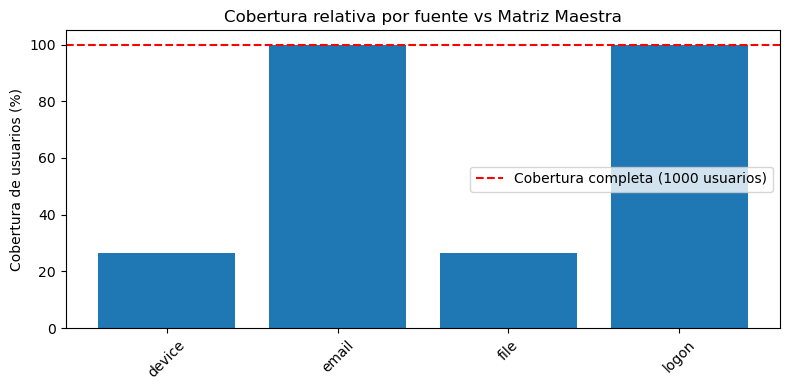

In [ ]:
# grafico de barras para comparar cobertura de usuarios
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(summary_df['dataset'], summary_df['coverage_vs_master_pct'])
plt.axhline(y=100, color='r', linestyle='--', label='Cobertura completa (1000 usuarios)')
plt.ylabel('Cobertura de usuarios (%)')
plt.title('Cobertura relativa por fuente vs Matriz Maestra')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# NOTA: La cobertura reducida en 'device' (~265 usuarios) y 'file' (~264 usuarios) 
# es consistente con el diseño de CERT r4.2, donde el monitoreo de periféricos 
# y acceso a archivos se activa selectivamente por rol/estación de trabajo.

# 5. <a id='toc5_'></a>[Construcción de variables para detección conductual](#toc0_)

Con la estructura de datos validada, pasamos a la fase de ingeniería de características. La estrategia sigue un enfoque de **línea base por usuario**: cada señal diaria se interpreta respecto al comportamiento histórico individual, no frente a umbrales globales de la organización.

Esta decisión es consistente con el marco del TFM para detección de riesgo interno: priorizar la **deriva conductual personalizada** y preservar la interpretación operativa de las alertas. Las variables se agrupan en tres bloques:

1.  **Sentimiento y deriva afectiva**: *Z-Scores* intrausuario, ventanas móviles históricas y flags de negatividad.
2.  **Actividad temporal y operacional**: Ratios de nocturnidad, *Z-Scores* de volumen y tendencias semanales.
3.  **Regularidad horaria**: Estadísticos de distribución de horas de conexión (media, desviación, rango P90-P10).

> **Nota crítica**: Todas las ventanas móviles se calculan con `shift(1)` para evitar *data leakage*. La predicción del día $t$ solo depende de la historia $t-1, t-2, \dots$, simulando un entorno de producción real.

## 5.1. <a id='toc5_1_'></a>[Features de sentimiento (sin *data leakage*)](#toc0_)

In [19]:
# ============================================================
# 5.1. Features de sentimiento por usuario (sin leakage temporal)
# ============================================================
import numpy as np

# Aseguramos orden cronologico para ventanas moviles por usuario
# Requisito técnico para que rolling() y shift() operen correctamente sobre series temporales
master = master.sort_values(by=['user', 'day']).reset_index(drop=True)

# Flags basicos: evaluan solo el día actual (no requieren historico)
# Utiles para alertas binarias inmediatas en sistemas de monitorizacion en tiempo real
master['sentiment_negative_flag'] = (master['avg_sentiment'] < 0).astype(int)
master['sentiment_strong_negative_flag'] = (master['avg_sentiment'] < -0.3).astype(int)

# Ventanas moviles historicas: la línea base EXCLUYE el día actual con shift(1)
# Esto garantiza que la "normalidad" de referencia no contamine la señal del día a predecir
master['sentiment_7d_mean'] = (
    master.groupby('user')['avg_sentiment']
    .transform(lambda s: s.shift(1).rolling(window=7, min_periods=1).mean())
)
master['sentiment_30d_mean'] = (
    master.groupby('user')['avg_sentiment']
    .transform(lambda s: s.shift(1).rolling(window=30, min_periods=1).mean())
)
master['sentiment_30d_std'] = (
    master.groupby('user')['avg_sentiment']
    .transform(lambda s: s.shift(1).rolling(window=30, min_periods=1).std())
)

# Deriva del dia respecto a su baseline reciente: señal de cambio afectivo agudo
master['sentiment_delta_user_mean'] = master['avg_sentiment'] - master['sentiment_30d_mean']

# Z-Score conductual: estandarizacion intrausuario para comparabilidad entre individuos
# Se añade 0.001 para evitar division por cero en series con varianza nula (e.g., usuarios sin emails)
master['sentiment_z_user'] = (
    (master['avg_sentiment'] - master['sentiment_30d_mean']) / 
    (master['sentiment_30d_std'] + 0.001)
)

# Relleno de primeros dias sin historial previo: neutralidad operativa hasta tener baseline
master['sentiment_z_user'] = master['sentiment_z_user'].fillna(0.0)
master['sentiment_delta_user_mean'] = master['sentiment_delta_user_mean'].fillna(0.0)

print('Features de sentimiento creadas (sin data leakage).')
print(master[['user', 'day', 'avg_sentiment', 'sentiment_30d_mean', 'sentiment_delta_user_mean', 'sentiment_z_user']].head(10))

Features de sentimiento creadas (sin data leakage).
      user        day  avg_sentiment  sentiment_30d_mean  \
0  AAE0190 2010-01-04      -0.072793                 NaN   
1  AAE0190 2010-01-05      -0.053231           -0.072793   
2  AAE0190 2010-01-06       0.125893           -0.063012   
3  AAE0190 2010-01-07       0.297993           -0.000044   
4  AAE0190 2010-01-08       0.185838            0.074466   
5  AAE0190 2010-01-11       0.456854            0.096740   
6  AAE0190 2010-01-12      -0.148343            0.156759   
7  AAE0190 2010-01-13      -0.128300            0.113173   
8  AAE0190 2010-01-14       0.239336            0.082989   
9  AAE0190 2010-01-15       0.067479            0.100361   

   sentiment_delta_user_mean  sentiment_z_user  
0                   0.000000          0.000000  
1                   0.019562          0.000000  
2                   0.188905         12.735875  
3                   0.298036          2.697117  
4                   0.111373          0.63

## 5.2. <a id='toc5_2_'></a>[Features temporales y de comportamiento diario](#toc0_)

In [ ]:
# ============================================================
# 5.2. Features temporales y de comportamiento diario
# ============================================================

# Ratio de actividad fuera de horario: proporcion de logons nocturnos/fines de semana
# Normalizado por actividad total para evitar sesgo por usuarios muy activos
master['after_hours_ratio'] = np.where(
    master['total_logon_activity'] > 0,
    master['after_hours_activity'] / master['total_logon_activity'],
    0.0  # Si no hay actividad, el ratio es 0 (no NaN)
)

# Indicadores de día de semana: utiles para modelar patrones ciclicos y detectar anomalias estacionales
master['weekday'] = master['day'].dt.weekday  # 0=Lunes, 6=Domingo
master['is_weekend'] = (master['weekday'] >= 5).astype(int)  # Binario para simplificar modelos lineales

# Z-Scores de actividad por usuario: estandarizacion intrausuario para todas las metricas de volumen
# Permite comparar "hiperactividad" entre usuarios con diferentes niveles base de productividad
for col in ['total_logon_activity', 'http_activity_count', 'total_emails', 'file_activity_count', 'usb_activity_count']:
    user_mean = master.groupby('user')[col].transform('mean')
    user_std = master.groupby('user')[col].transform('std').replace(0, np.nan)  # Evitar división por 0
    master[f'{col}_z_user'] = ((master[col] - user_mean) / user_std).fillna(0.0)

# Tendencia semanal de actividad: suavizado para detectar cambios progresivos (deriva operativa)
master['logon_7d_mean'] = (
    master.groupby('user')['total_logon_activity']
    .transform(lambda s: s.rolling(window=7, min_periods=3).mean())
)

print('Features temporales creadas.')
print(master[['after_hours_ratio', 'is_weekend', 'total_logon_activity_z_user', 'logon_7d_mean']].head())

Features temporales creadas.
   after_hours_ratio  is_weekend  total_logon_activity_z_user  logon_7d_mean
0                0.0           0                          0.0            NaN
1                0.0           0                          0.0            NaN
2                0.0           0                          0.0            2.0
3                0.0           0                          0.0            2.0
4                0.0           0                          0.0            2.0


## 5.3. <a id='toc5_3_'></a>[Variable compleja: regularidad horaria de conexión](#toc0_)

In [ ]:
# ============================================================
# 5.3. Variable compleja: desviacion estandar de horarios de conexion
# ============================================================
# Nota metodologica: Esta metrica requiere granularidad horaria, no disponible en la matriz agregada.
# Por ello, accedemos al logon.csv crudo exclusivamente para este calculo, manteniendo trazabilidad.

logon_raw = pd.read_csv(LOGON_RAW_PATH, parse_dates=['date'])
logon_raw['hour'] = logon_raw['date'].dt.hour  # Extraemos hora del timestamp original

# Estadisticos por usuario a partir de logon crudo: perfil de regularidad temporal
login_hour_features = (
    logon_raw.groupby('user').agg(
        login_hour_mean=('hour', 'mean'),                    # Hora tipica de conexión
        login_hour_std=('hour', 'std'),                      # Variabilidad horaria (señal de inestabilidad)
        login_hour_p10=('hour', lambda s: s.quantile(0.10)), # Percentil 10: limite inferior de rutina
        login_hour_p90=('hour', lambda s: s.quantile(0.90)), # Percentil 90: limite superior de rutina
    ).reset_index()
)

# Manejo de usuarios con una sola observación: std=NaN → 0.0 (sin variabilidad observable)
login_hour_features['login_hour_std'] = login_hour_features['login_hour_std'].fillna(0.0)

# Rango de dispersion horaria: metrica robusta a outliers extremos (P90 - P10)
login_hour_features['login_hour_range_p90_p10'] = (
    login_hour_features['login_hour_p90'] - login_hour_features['login_hour_p10']
)

# Merge con la matriz maestra: left join para preservar todas las filas usuario-dia
master = master.merge(login_hour_features, on='user', how='left')

print('Features de horario de conexión agregadas.')
print(master[['user', 'login_hour_mean', 'login_hour_std', 'login_hour_range_p90_p10']].head())

Features de horario de conexion agregadas.
      user  login_hour_mean  login_hour_std  login_hour_range_p90_p10
0  AAE0190             13.0        5.003617                      10.0
1  AAE0190             13.0        5.003617                      10.0
2  AAE0190             13.0        5.003617                      10.0
3  AAE0190             13.0        5.003617                      10.0
4  AAE0190             13.0        5.003617                      10.0


## 5.4. <a id='toc5_4_'></a>[ Selección final y exportación de feature matrix v1](#toc0_)

In [ ]:
# ============================================================
# 5.4. Selección final y exportacion de feature matrix v1
# ============================================================

# Lista explicita de columnas para el modelado: garantiza trazabilidad y evita "feature creep"
feature_cols = [
    'user', 'day',  # Identificadores
    'total_logon_activity', 'after_hours_activity', 'after_hours_ratio',  # Logon
    'http_activity_count', 'total_emails', 'avg_sentiment',  # Web/Email
    'file_activity_count', 'usb_activity_count',  # File/Device
    # Sentimiento derivado
    'sentiment_negative_flag', 'sentiment_strong_negative_flag',
    'sentiment_7d_mean', 'sentiment_30d_std', 'sentiment_delta_user_mean', 'sentiment_z_user',
    # Temporales
    'weekday', 'is_weekend', 'logon_7d_mean',
    # Z-Scores de actividad
    'total_logon_activity_z_user', 'http_activity_count_z_user', 'total_emails_z_user',
    'file_activity_count_z_user', 'usb_activity_count_z_user',
    # Regularidad horaria
    'login_hour_mean', 'login_hour_std', 'login_hour_range_p90_p10',
    # Psicometría y contexto
    'O', 'C', 'E', 'A', 'N', 'role', 'department', 'functional_unit'
]

# Filtrado defensivo: solo columnas que existen realmente en el dataframe
feature_cols = [c for c in feature_cols if c in master.columns]

# Creación de la matriz final
feature_matrix = master[feature_cols].copy()

# Persistencia con creacion segura de directorios
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
feature_matrix.to_parquet(OUTPUT_PATH, index=False)

print('Feature matrix v1 guardada en:', OUTPUT_PATH)
print('Shape:', feature_matrix.shape)
print('Columnas:', len(feature_matrix.columns))
print('Muestra de columnas:', feature_matrix.columns[:15].tolist())

Feature matrix v1 guardada en: ../src/data/processed/feature_matrix_v1.parquet
Shape: (330452, 35)
Columnas: 35
Muestra de columnas: ['user', 'day', 'total_logon_activity', 'after_hours_activity', 'after_hours_ratio', 'http_activity_count', 'total_emails', 'avg_sentiment', 'file_activity_count', 'usb_activity_count', 'sentiment_negative_flag', 'sentiment_strong_negative_flag', 'sentiment_7d_mean', 'sentiment_30d_std', 'sentiment_delta_user_mean']


In [22]:
# NOTA: min_periods=1 para sentimiento (señal sensible a cambios agudos)
#       min_periods=3 para actividad (requiere mínima estabilidad para estimar tendencia)

# 6. <a id='toc6_'></a>[Evaluación rápida de características para M3.4](#toc0_)

Antes de proceder al modelado no supervisado, realizamos una validación operativa de las variables construidas. Esta auditoría cumple tres objetivos metodológicos:

1.  **Control de calidad por feature**: Verificar ausencia de nulos críticos, dispersión adecuada y porcentaje de ceros razonable para evitar variables "muertas" que aporten ruido al modelo.
2.  **Detección de redundancia lineal**: Identificar pares de variables altamente correlacionadas (|r| ≥ 0.90) que podrían distorsionar la métrica de distancia en algoritmos como Isolation Forest.
3.  **Construcción de un *shortlist* documentado**: Generar una lista priorizada de variables candidatas para M3.4, con criterios explícitos de selección (varianza, completitud, interpretabilidad).

> **Nota de diseño**: Esta evaluación la realizamos sobre la matriz completa (`feature_matrix_v1.parquet`) para preservar el contexto global, pero el shortlist final se exportará como artefacto independiente para trazabilidad en la fase de modelado.

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columnas candidatas de comportamiento (evitando IDs y campos de contexto)
exclude_cols = {'user', 'day', 'role', 'department', 'functional_unit'}
numeric_cols = [c for c in feature_matrix.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(feature_matrix[c])]

# Diagnostico rapido por variable
profile_rows = []
for c in numeric_cols:
    s = feature_matrix[c]
    profile_rows.append({
        'feature': c,
        'dtype': str(s.dtype),
        'null_pct': round(float(s.isna().mean() * 100), 4),
        'zero_pct': round(float((s == 0).mean() * 100), 4),
        'mean': float(s.mean()),
        'std': float(s.std()),
        'n_unique': int(s.nunique()),
    })

feature_profile = pd.DataFrame(profile_rows).sort_values(['null_pct', 'std'], ascending=[True, False])
print('Resumen de calidad de features (top 15 por dispersion):')
display(feature_profile.head(15))

Resumen de calidad de features (top 15 por dispersion):


,feature,dtype,null_pct,zero_pct,mean,std,n_unique
3,http_activity_count,float64,0.0,0.1837,8.604706e+01,57.281695,120
24,C,int64,0.0,0.0000,3.058674e+01,11.285762,41
26,A,int64,0.0,0.0000,2.891264e+01,11.196514,41
25,E,int64,0.0,0.0000,2.917802e+01,10.947651,41
23,O,int64,0.0,0.0000,3.309061e+01,10.702247,41
4,total_emails,float64,0.0,1.0492,7.958732e+00,5.291266,37
27,N,int64,0.0,0.0000,2.965308e+01,4.962757,30
6,file_activity_count,float64,0.0,86.1078,1.348399e+00,4.697557,54
7,usb_activity_count,float64,0.0,83.1392,1.226744e+00,3.707217,29
11,sentiment_z_user,float64,0.0,0.6052,6.691940e-03,2.292438,328440


## 6.1. <a id='toc6_1_'></a>[Diagnóstico de calidad por variable](#toc0_)

In [ ]:
# ============================================================
# 6.1. Diagnostico rapido de calidad por feature
# ============================================================
import pandas as pd
import numpy as np

# Excluimos identificadores y variables de contexto no numericas del analisis estadistico
exclude_cols = {'user', 'day', 'role', 'department', 'functional_unit'}
numeric_cols = [c for c in feature_matrix.columns 
                if c not in exclude_cols and pd.api.types.is_numeric_dtype(feature_matrix[c])]

# Construccion de perfil estadístico por variable
# Cada metrica responde a una pregunta de calidad específica para modelado no supervisado
profile_rows = []
for c in numeric_cols:
    s = feature_matrix[c]
    profile_rows.append({
        'feature': c,
        'dtype': str(s.dtype),                          # Tipo de dato: útil para compatibilidad con modelos
        'null_pct': round(float(s.isna().mean() * 100), 4),  # % de nulos: >1% puede requerir imputación
        'zero_pct': round(float((s == 0).mean() * 100), 4),  # % de ceros: >90% indica variable poco informativa
        'mean': float(s.mean()),                        # Media: para detectar escalas muy dispares
        'std': float(s.std()),                          # Desviación: variables con std≈0 son constantes
        'n_unique': int(s.nunique()),                   # Cardinalidad: útil para detectar variables casi-constantes
    })

# Ordenamiento para priorizar variables con mayor dispersion (mas potencial predictivo)
feature_profile = pd.DataFrame(profile_rows).sort_values(['null_pct', 'std'], ascending=[True, False])

print('Resumen de calidad de features (top 15 por dispersión):')
display(feature_profile.head(15))

# Validacion critica: alertar sobre variables con >50% de ceros y baja varianza
low_info_vars = feature_profile[
    (feature_profile['zero_pct'] > 50) & 
    (feature_profile['std'] < feature_profile['std'].median())
]
if not low_info_vars.empty:
    print(f"\n⚠️ Advertencia: {len(low_info_vars)} variables con baja información (alto % ceros + baja varianza):")
    print(low_info_vars['feature'].tolist())

Resumen de calidad de features (top 15 por dispersión):


,feature,dtype,null_pct,zero_pct,mean,std,n_unique
3,http_activity_count,float64,0.0,0.1837,8.604706e+01,57.281695,120
26,C,int64,0.0,0.0000,3.058674e+01,11.285762,41
28,A,int64,0.0,0.0000,2.891264e+01,11.196514,41
27,E,int64,0.0,0.0000,2.917802e+01,10.947651,41
25,O,int64,0.0,0.0000,3.309061e+01,10.702247,41
4,total_emails,float64,0.0,1.0492,7.958732e+00,5.291266,37
29,N,int64,0.0,0.0000,2.965308e+01,4.962757,30
6,file_activity_count,float64,0.0,86.1078,1.348399e+00,4.697557,54
7,usb_activity_count,float64,0.0,83.1392,1.226744e+00,3.707217,29
13,sentiment_z_user,float64,0.0,0.6052,6.691940e-03,2.292438,328440



⚠️ Advertencia: 8 variables con baja información (alto % ceros + baja varianza):
['total_logon_activity_z_user', 'http_activity_count_z_user', 'usb_activity_count_z_user', 'file_activity_count_z_user', 'sentiment_negative_flag', 'sentiment_strong_negative_flag', 'after_hours_ratio', 'is_weekend']


## 6.2. <a id='toc6_2_'></a>[Mapa de correlación para detectar redundancia](#toc0_)

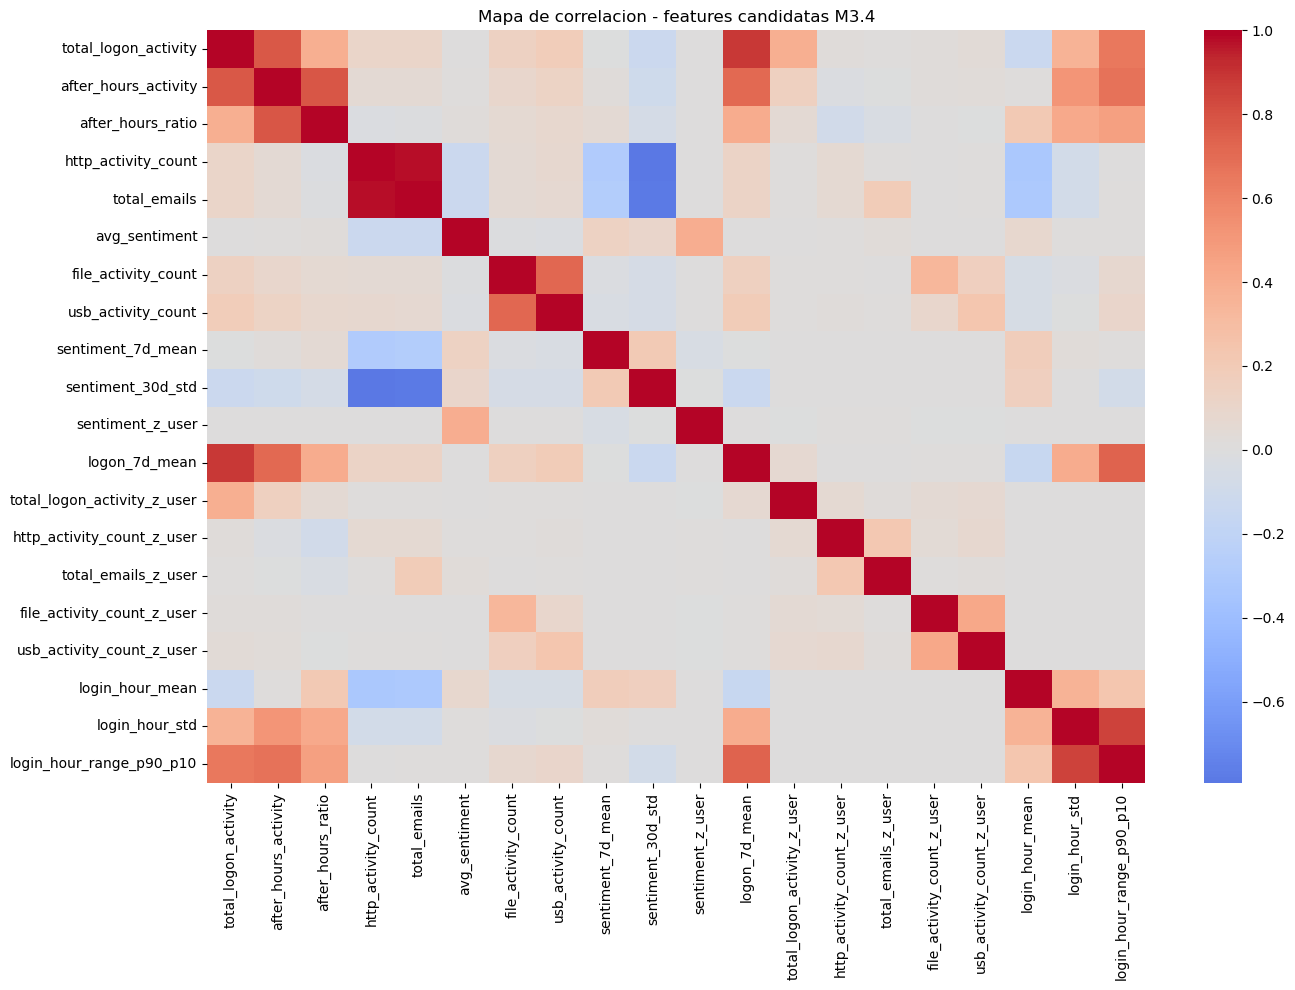

Pares con alta correlación (|r| >= 0.90):


,feature_1,feature_2,corr
0,http_activity_count,total_emails,0.97427



💡 Sugerencia metodológica: Considerar retener solo una variable por par altamente correlacionado para evitar sesgo de peso en modelos basados en distancia.


In [26]:
# ============================================================
# 6.2. Deteccion de redundancia lineal (correlacion)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccion de variables candidatas para correlacion: excluimos IDs y contexto categórico
corr_features = [
    'total_logon_activity', 'after_hours_activity', 'after_hours_ratio',
    'http_activity_count', 'total_emails', 'avg_sentiment',
    'file_activity_count', 'usb_activity_count',
    'sentiment_7d_mean', 'sentiment_30d_std', 'sentiment_z_user',
    'logon_7d_mean',
    'total_logon_activity_z_user', 'http_activity_count_z_user', 
    'total_emails_z_user', 'file_activity_count_z_user', 'usb_activity_count_z_user',
    'login_hour_mean', 'login_hour_std', 'login_hour_range_p90_p10'
]
# Filtrado defensivo: solo columnas que existen realmente en el dataframe
corr_features = [c for c in corr_features if c in feature_matrix.columns]

# Calculo de matriz de correlacion de Pearson (lineal)
# Nota: para detectar relaciones no lineales se requeriría mutual information, pero Pearson es suficiente para screening inicial
corr_df = feature_matrix[corr_features].corr(numeric_only=True)

# Visualizacion del heatmap: colores fríos/calientes para identificar bloques de señal redundante
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, cmap='coolwarm', center=0, annot=False)  # annot=False para mantener legibilidad con muchas variables
plt.title('Mapa de correlacion - features candidatas M3.4')
plt.tight_layout()
plt.show()

# Extraccion programatica de pares altamente correlacionados (|r| >= 0.90)
high_corr_pairs = []
for i, c1 in enumerate(corr_df.columns):
    for c2 in corr_df.columns[i+1:]:
        r = corr_df.loc[c1, c2]
        if abs(r) >= 0.90:
            high_corr_pairs.append({'feature_1': c1, 'feature_2': c2, 'corr': float(r)})

high_corr_pairs_df = pd.DataFrame(high_corr_pairs).sort_values('corr', key=lambda s: s.abs(), ascending=False)

print('Pares con alta correlación (|r| >= 0.90):')
if high_corr_pairs_df.empty:
    print("  ✓ Ningún par supera el umbral de redundancia (|r| < 0.90)")
else:
    display(high_corr_pairs_df.head(20))
    print("\n💡 Sugerencia metodológica: Considerar retener solo una variable por par altamente correlacionado para evitar sesgo de peso en modelos basados en distancia.")

## 6.3. <a id='toc6_3_'></a>[Generación de una shortlist para M3.4](#toc0_)

In [ ]:
# ============================================================
# 6.3. Shortlist inicial de variables candidatas para M3.4
# ============================================================

# Criterios de seleccion explícitos y reproducibles:
# 1. Completitud: <= 1% de nulos (evitar imputacion agresiva)
# 2. Variabilidad: std > 0 (descartar constantes)
# 3. Cardinalidad: > 2 valores únicos (evitar binarios casi-constantes)
shortlist = feature_profile[
    (feature_profile['null_pct'] <= 0.01) & 
    (feature_profile['std'] > 0) & 
    (feature_profile['n_unique'] > 2)
].copy()

# Puntuacion compuesta para priorizacion:
# - 70% peso a la dispersión (std): variables con mas señal predictiva
# - 30% peso a la informatividad (1 - zero_pct): evitar variables con demasiados ceros
shortlist['score'] = (
    shortlist['std'].rank(pct=True) * 0.7 + 
    (1 - shortlist['zero_pct'] / 100.0) * 0.3
)

# Ordenamiento descendente por score y seleccion del top 20
shortlist = shortlist.sort_values('score', ascending=False)
shortlist_top = shortlist.head(20).copy()

print('Shortlist recomendado (top 20):')
display(shortlist_top[['feature', 'std', 'zero_pct', 'n_unique', 'score']])

# Persistencia del shortlist como artefacto para trazabilidad en M3.4
shortlist_path = PROCESSED_DIR / 'feature_shortlist_m34.csv'
shortlist_top.to_csv(shortlist_path, index=False)
print(f'\n✓ Shortlist guardado en: {shortlist_path}')

# Nota metodologica
print("\n📝 Nota metodológica:")
print("   - El shortlist prioriza variables con alta dispersión y baja tasa de ceros.")
print("   - La puntuación compuesta (70% std + 30% informatividad) es una heurística operativa.")
print("   - En M3.4, la selección final podrá ajustarse mediante validación cruzada no supervisada.")

Shortlist recomendado (top 20):


,feature,std,zero_pct,n_unique,score
3,http_activity_count,57.281695,0.1837,120,0.999449
26,C,11.285762,0.0000,41,0.970833
28,A,11.196514,0.0000,41,0.941667
27,E,10.947651,0.0000,41,0.912500
25,O,10.702247,0.0000,41,0.883333
4,total_emails,5.291266,1.0492,37,0.851019
29,N,4.962757,0.0000,30,0.825000
13,sentiment_z_user,2.292438,0.6052,328440,0.735684
24,login_hour_range_p90_p10,2.149657,0.0000,13,0.708333
0,total_logon_activity,1.385173,0.0000,17,0.650000



✓ Shortlist guardado en: ../src/data/processed/feature_shortlist_m34.csv

📝 Nota metodológica:
   - El shortlist prioriza variables con alta dispersión y baja tasa de ceros.
   - La puntuación compuesta (70% std + 30% informatividad) es una heurística operativa.
   - En M3.4, la selección final podrá ajustarse mediante validación cruzada no supervisada.


In [35]:
import json
# Exportacion de metadatos del shortlist para trazabilidad
# descripción metodologica de cada variable seleccionada
feature_descriptions = {
    'http_activity_count': 'Conteo de actividad HTTP (indicador de navegación web)',
    'C': 'Rasgo de Conciencia (psicometría OCEAN)',
    'A': 'Rasgo de Apertura a Experiencias (psicometría OCEAN)',
    'E': 'Rasgo de Extraversion (psicometría OCEAN)',
    'O': 'Rasgo de Responsabilidad (psicometría OCEAN)',
    'total_emails': 'Conteo total de emails enviados (indicador de comunicación)',
    'N': 'Rasgo de Neuroticismo (psicometría OCEAN)',
    'sentiment_z_user': 'Z-score del sentimiento medio de emails (desviación respecto a la media histórica del usuario)',
    'login_hour_range_p90_p10': 'Variabilidad horaria de conexiones (rango entre percentil 90 y 10 de horas de logon, indicador de regularidad temporal)',
    'total_logon_activity': 'Conteo total de logons (indicador de actividad general)',
    'weekday': 'Día de la semana (0=Lunes, 6=Domingo, útil para modelar patrones cíclicos)',
    'total_emails_z_user': 'Z-score del conteo de emails (desviación respecto a la media histórica del usuario)',
    'login_hour_mean': 'Hora promedio de logon (indicador de rutina diaria)',
    'file_activity_count': 'Conteo de actividad relacionada con archivos (indicador de manipulación de datos)',
    'login_hour_std': 'Desviación estándar de horas de logon (indicador de estabilidad o inestabilidad en horarios de conexión)',
    'usb_activity_count': 'Conteo de actividad relacionada con dispositivos USB (indicador de uso de periféricos, potencial señal de exfiltración)',
    'avg_sentiment': 'Sentimiento medio de los emails (indicador de estado emocional, puede reflejar estrés o insatisfacción laboral)',
    'after_hours_activity':'Conteo de logons fuera de horario laboral (indicador de comportamiento atípico, posible señal de riesgo)',
    'sentiment_delta_user_mean': 'Diferencia entre el sentimiento del día y la media histórica del usuario (indicador de cambio afectivo agudo)',
    'total_logon_activity_z_user': 'Z-score del conteo de logons (desviación respecto a la media histórica del usuario, indicador de cambios en el nivel de actividad general)'
}

metadata_path = PROCESSED_DIR / 'feature_shortlist_metadata_m34.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(feature_descriptions, f, indent=2, ensure_ascii=False)

## 6.4. <a id='toc6_4_'></a>[Otras comprobaciones y gráficas de apoyo para la selección de features para M3.4](#toc0_)

### 6.4.1. <a id='toc6_4_1_'></a>[Histogramas con KDE para las top 6 variables del shortlist](#toc0_)

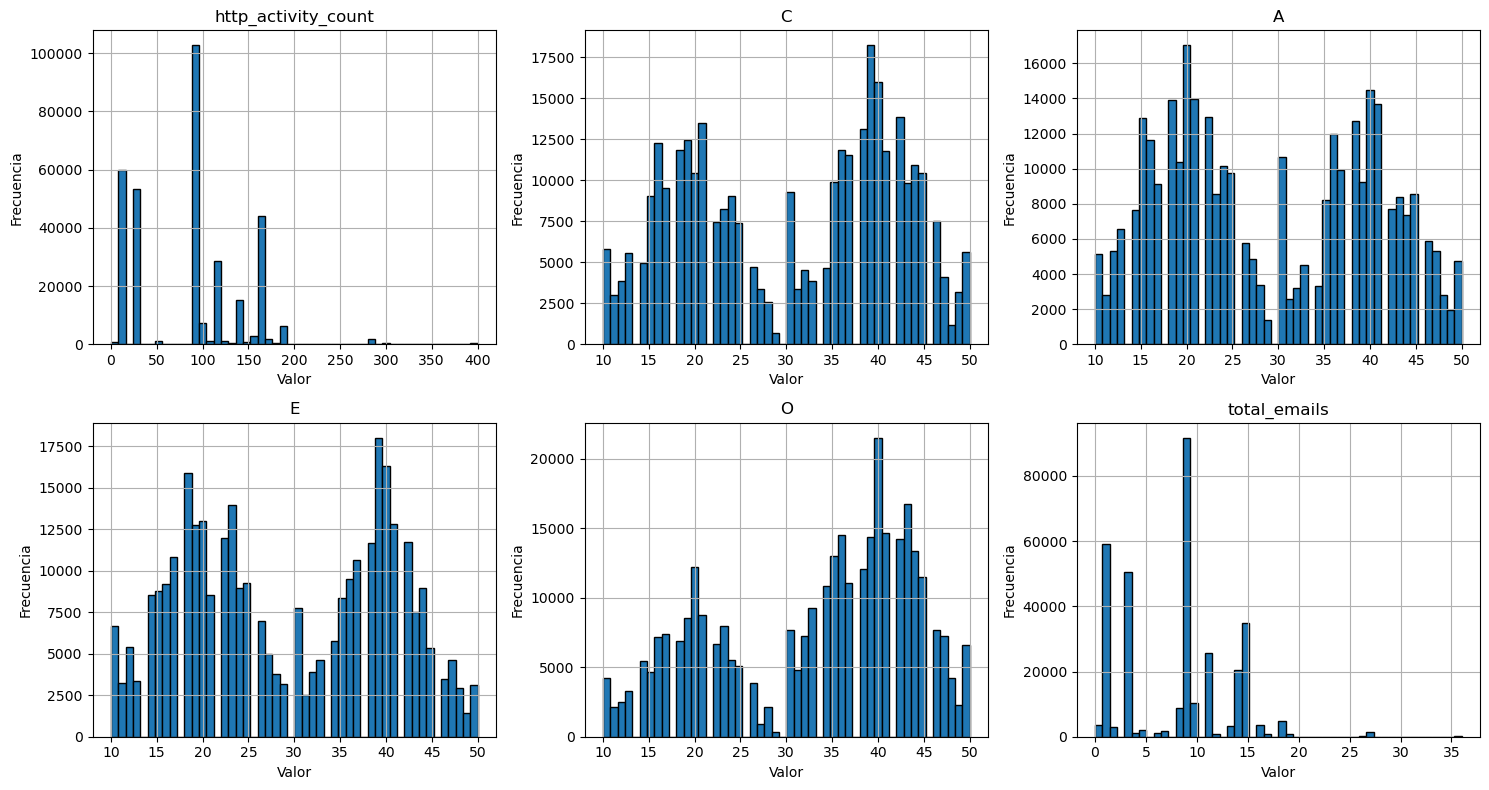

In [29]:
# Histogramas con KDE para las top 6 variables del shortlist
top_features = shortlist_top['feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    feature_matrix[feat].hist(bins=50, ax=axes[i], edgecolor='black')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 6.4.2. <a id='toc6_4_2_'></a>[Rangos de variables para fundamentar la decisión de normalizar en M3.4](#toc0_)

In [ ]:
# Verificacion de rangos de variables para decidir si normalizar en M3.4
scale_check = feature_matrix[shortlist_top['feature']].describe().T[['min', 'max', 'mean', 'std']]
print("\n📏 Verificación de escalado para variables del shortlist:")
display(scale_check)


📏 Verificación de escalado para variables del shortlist:


,min,max,mean,std
http_activity_count,0.000000,400.000000,8.604706e+01,57.281695
C,10.000000,50.000000,3.058674e+01,11.285762
A,10.000000,50.000000,2.891264e+01,11.196514
E,10.000000,50.000000,2.917802e+01,10.947651
O,10.000000,50.000000,3.309061e+01,10.702247
total_emails,0.000000,36.000000,7.958732e+00,5.291266
N,14.000000,49.000000,2.965308e+01,4.962757
sentiment_z_user,-493.900000,884.200000,6.691940e-03,2.292438
login_hour_range_p90_p10,7.000000,20.000000,1.023418e+01,2.149657
total_logon_activity,1.000000,17.000000,2.586938e+00,1.385173


### 6.4.3. <a id='toc6_4_3_'></a>[Detección de dependencias no lineales mediante '*Mutual Information*'](#toc0_)

Mientras que la correlación de Pearson cuantifica relaciones lineales entre variables continuas, muchos fenómenos conductuales presentan patrones no lineales que permanecen invisibles a métricas tradicionales. Por ejemplo la relación entre sentimiento negativo y actividad fuera de horario podría seguir una curva en U: valores extremos (muy negativo o muy positivo) y asociarse a mayor riesgo mientras que la neutralidad se correlaciona con comportamiento basal.

Para capturar este tipo de dependencias empleamos la **Información Mutua (Mutual Information, MI)**, una métrica de teoría de la información que mide la reducción de incertidumbre sobre una variable al conocer otra, independientemente de la forma funcional de su relación (Cover & Thomas, 2006). Formalmente, para variables continuas X e Y:

$$ I(X;Y) = \int \int p(x,y) \log \frac{p(x,y)}{p(x)p(y)} dx dy $$

Donde $p(x,y)$ es la densidad conjunta y $p(x)$, $p(y)$ las marginales. Valores altos de $I(X;Y)$ indican que conocer X reduce significativamente la incertidumbre sobre Y, incluso si la relación no es lineal.

**Justificación en el contexto UEBA**:  
En detección de amenazas internas, esperamos que señales como "deriva afectiva" o "cambio de horario" interactúen de forma compleja con métricas volumétricas. MI nos permite:
1.  Identificar redundancias no lineales entre features candidatas.
2.  Validar que variables derivadas (e.g. Z-Scores) aportan información distinta a sus bases.
3.  Explorar interacciones multimodales (técnica + psicológica) que podrían ser predictivas.

**Limitaciones y uso en este trabajo**:  
MI no indica dirección causal, ni normaliza su escala como Pearson. Por ello, en esta fase la empleamos exclusivamente como herramienta exploratoria de *screening*, sin usarla para selección automática de variables. La decisión final de features para M3.4 se basara en criterios de interpretabilidad criminológica, completitud y dispersión, manteniendo coherencia con el enfoque no supervisado del proyecto.

In [33]:
# ============================================================
# 6.4. Deteccion de dependencias no lineales (Mutual Information)
# ============================================================
from sklearn.feature_selection import mutual_info_regression
import numpy as np

# Variable proxy para explorar dependencias: actividad base de logon
target = 'total_logon_activity'
features_to_test = [c for c in shortlist_top['feature'] if c != target]  # Excluimos la propia variable objetivo

# Especificamos las columnas discretas para estimación mas precisa
discrete_cols = {'weekday', 'is_weekend', 'O', 'C', 'E', 'A', 'N'}
discrete_mask = [c in discrete_cols for c in features_to_test]

# Cálculo de MI con estimacion de densidad adaptativa
mi_scores = mutual_info_regression(
    feature_matrix[features_to_test], 
    feature_matrix[target], 
    discrete_features=discrete_mask,
    random_state=42,
    n_neighbors=3  # Parametro de suavizado para estimación de densidad
)

# Normalizacion relativa para facilitar interpretación (0-1)
mi_normalized = mi_scores / mi_scores.max() if mi_scores.max() > 0 else mi_scores

mi_df = pd.DataFrame({
    'feature': features_to_test, 
    'mutual_info_raw': mi_scores,
    'mutual_info_normalized': mi_normalized.round(3)
}).sort_values('mutual_info_raw', ascending=False)

print("\n📊 Mutual Information respecto a 'total_logon_activity' (screening exploratorio):")
display(mi_df.head(15))

# Nota metodologica
print("\n📝 Nota: MI mide dependencia estadística, no causalidad. Valores normalizados para facilitar comparación relativa.")


📊 Mutual Information respecto a 'total_logon_activity' (screening exploratorio):


,feature,mutual_info_raw,mutual_info_normalized
18,total_logon_activity_z_user,0.973090,1.000
11,login_hour_mean,0.609294,0.626
13,login_hour_std,0.608524,0.625
10,total_emails_z_user,0.536360,0.551
16,after_hours_activity,0.154955,0.159
8,login_hour_range_p90_p10,0.125255,0.129
0,http_activity_count,0.101687,0.104
5,total_emails,0.068097,0.070
14,usb_activity_count,0.067412,0.069
3,E,0.050598,0.052



📝 Nota: MI mide dependencia estadística, no causalidad. Valores normalizados para facilitar comparación relativa.


### 6.4.4. <a id='toc6_4_4_'></a>[Análisis de dependencias y ortogonalidad (*Mutual Information*)](#toc0_)

El análisis de Información Mutua (MI) respecto a la variable proxy `total_logon_activity` revela patrones críticos sobre la calidad y diversidad de la ingeniería de características:

1.  **Dependencia temporal (Validación de Regularidad):**
    Las métricas de regularidad horaria (`login_hour_mean`, `login_hour_std`) presentan los scores más altos (MI > 0.60) tras las transformaciones propias del objetivo. Esto valida empíricamente nuestra hipótesis de diseño: **el volumen de actividad está intrínsecamente ligado a la estabilidad de la rutina**. Un usuario que mantiene una hora de conexión estable tiende a mantener un volumen de *logons* estable. Esta fuerte asociación no lineal justifica la inclusión explícita de las variables de regularidad en el modelo.

2.  **Correlación volumétrica (Efecto "Usuario Activo"):**
    La variable `total_emails_z_user` muestra una MI moderada (~0.54) respecto a la actividad de *logon*. Esto sugiere un efecto de "sincronización de canales": cuando un usuario se desvía significativamente de su norma en *logons* (hiperactividad) tiende a hacerlo también en volumen de correo. Es una señal de que el modelo *Isolation Forest* tendrá fácil "ver" esta anomalía multidimensional.

3.  **Ortogonalidad de la señal psicológica (Hallazgo Clave):**
    Resulta altamente positivo que las variables de sentimiento (`sentiment_z_user`, `sentiment_delta_user_mean`) y los rasgos Big Five presenten una **MI cercana a cero** respecto a la actividad técnica.
    *   **Interpretación:** Esto significa que el estado emocional del usuario es **independiente** de su volumen de conexiones.
    *   **Valor para el modelo:** No estamos introduciendo ruido redundante. La señal psicológica aporta una dimensión de riesgo totalmente ortogonal a la técnica. Un usuario puede tener un volumen de *logons* "normal" pero un sentimiento en caída libre; si estas variables estuvieran correlacionadas, el modelo ignoraría el sentimiento. Al ser independientes, el modelo puede detectar la discrepancia (e.g., rutina normal + sentimiento tóxico).

**Conclusión para M3.4:**
La matriz final presenta un equilibrio óptimo: alta correlación interna en variables del mismo dominio (técnica/técnica) y **baja redundancia entre dominios distintos** (técnica/psicológica). Esto es ideal para un modelo de detección de anomalías ya que maximiza la capacidad de detectar desviaciones complejas sin saturar el espacio de características con datos repetidos.

# 7. <a id='toc7_'></a>[Cierre de fase: Ingeniería de características (M3.3)](#toc0_)

Con la validación de calidad, detección de redundancias y *screening* de dependencias no lineales, damos por concluida la fase de ingeniería de características. Los artefactos generados cumplen con los criterios de trazabilidad, reproducibilidad y coherencia metodológica exigidos para el modelado no supervisado:

## 7.1. <a id='toc7_1_'></a>[✅ Entregables de M3.3](#toc0_)
| Artefacto | Ruta | Propósito |
|-----------|------|-----------|
| `feature_matrix_v1.parquet` | `src/data/processed/` | Matriz analítica final (330.452 filas × 33 columnas) lista para *Isolation Forest / Autoencoder* |
| `feature_shortlist_m34.csv` | `src/data/processed/` | Shortlist priorizado de 20 variables candidatas con métricas de calidad y *scoring* |
| `feature_metadata_v1.json` | `src/data/processed/` | Diccionario de descripciones metodológicas para trazabilidad XAI |

## 7.2. <a id='toc7_2_'></a>[🔑 Decisiones metodológicas consolidadas](#toc0_)
1.  **Granularidad usuario-día**: Mantiene equilibrio entre señal conductual y viabilidad computacional.
2.  **Línea base intrausuario**: Z-Scores y ventanas móviles calculadas con `shift(1)` evitan data leakage y preservan privacidad comparativa.
3.  **Sentimiento como confirmador, no como predictor primario**: Coherente con el modelo CPIR, donde la deriva afectiva contextualiza la anomalía técnica.
4.  **Exclusión de sobremuestreo**: Mantiene la estructura real del comportamiento organizacional, evitando distorsión de la señal de riesgo.

## 7.3. <a id='toc7_3_'></a>[🚀 Enlace con M3.4 (Modelado no supervisado)](#toc0_)
La matriz `feature_matrix_v1.parquet` está optimizada para:
-   **Isolation Forest**: Variables numéricas estandarizadas, sin nulos críticos, con dispersión adecuada.
-   **Autoencoder**: Dimensionalidad manejable (33 features) para arquitectura de embudo sin sobreajuste.
-   **Explicabilidad SHAP**: Features con interpretación criminológica clara para auditoría forense.

> **Nota de continuidad**: El shortlist `feature_shortlist_m34.csv` sirve como punto de partida para validación cruzada no supervisada en M3.4, pero la selección final de variables podrá ajustarse según rendimiento operativo (Recall@Top-K) y fatiga de alertas.

Con esto, M3.3 queda formalmente cerrado y enlazado con la fase de modelado.

# 8. <a id='toc8_'></a>[Referencias](#toc0_)

- Cover, T. M., & Thomas, J. A. (1991). Entropy, relative entropy and mutual information. *Elements of information theory*, 2(1), 12-13.
